In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [32]:
summary_path = Path("/Users/bigrorz/UnityProjects/MultipleStyleRendering/ProfilingLogs/summary.csv")

raw_df = pd.read_csv(summary_path)

group_cols = [
    "test_name",
    "scene",
    "variable",
    "value",
    "render_mode",
    "N",
    "K",
    "styles_per_object",
]

metric_cols = [
    "mean_cpu_ms",
    "median_cpu_ms",
    "p95_cpu_ms",
    "p99_cpu_ms",
    "max_cpu_ms",
    "std_cpu_ms",
    "mean_gpu_ms",
    "median_gpu_ms",
    "p95_gpu_ms",
    "p99_gpu_ms",
    "max_gpu_ms",
    "std_gpu_ms",
]

agg_df = (
    raw_df.groupby(group_cols, as_index=False)[metric_cols]
    .mean()
    .sort_values(["test_name", "render_mode", "value"])
)

test_dfs = {
    test_name: df.sort_values(["value", "render_mode"]).reset_index(drop=True)
    for test_name, df in agg_df.groupby("test_name")
}

print("Loaded tests:")
for name, df in test_dfs.items():
    print(f"  {name}: {len(df)} rows")


Loaded tests:
  BBoxCountScaling_RandomMultiStyle: 19 rows
  BBoxCountScaling_SameStyle: 24 rows


In [33]:
list(test_dfs.keys())

['BBoxCountScaling_RandomMultiStyle', 'BBoxCountScaling_SameStyle']

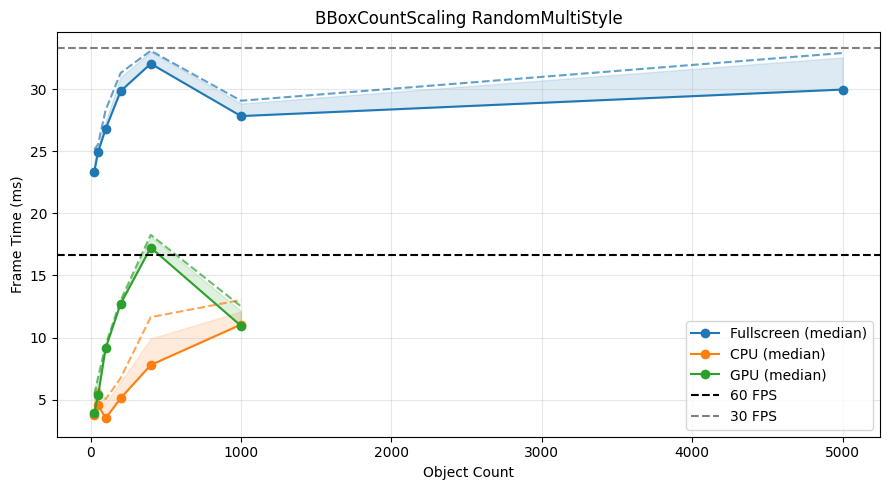

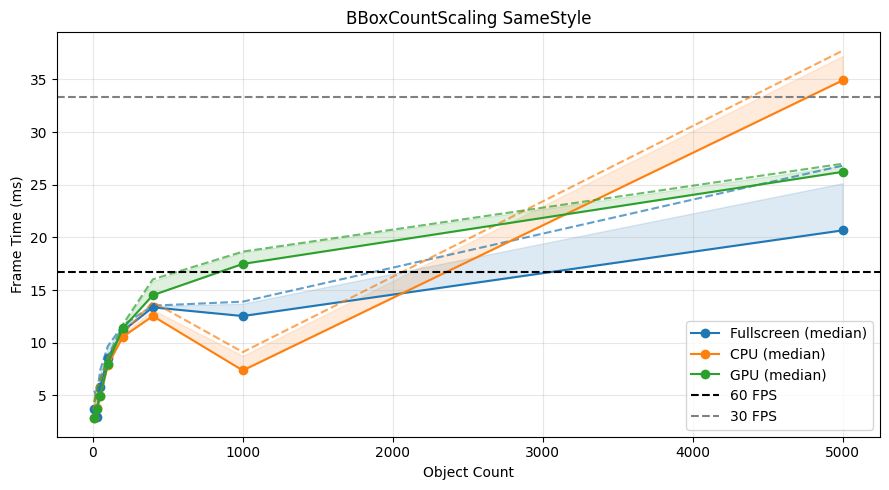

In [34]:
# consistent colours
mode_colors = {
    "Fullscreen": "C0",
    "CPU": "C1",
    "GPU": "C2",
}

# pretty names for variables
variable_labels = {
    "N": "Total Styles (N)",
    "K": "Active Styles (K)",
    "StylesPerObject": "Styles per Object",
    "ObjectCount": "Object Count",
    "Coverage": "Coverage (%)",
}

def format_title(name):
    return name.replace("_", " ")

for test_name, test_df in test_dfs.items():
    test_df = test_df.sort_values(["value", "render_mode"])

    plt.figure(figsize=(9, 5))

    for render_mode in ["Fullscreen", "CPU", "GPU"]:
        mode_df = test_df[test_df["render_mode"] == render_mode].sort_values("value")

        if mode_df.empty:
            continue

        x = mode_df["value"].values
        median = mode_df["median_gpu_ms"].values
        p95 = mode_df["p95_gpu_ms"].values
        p99 = mode_df["p99_gpu_ms"].values

        color = mode_colors[render_mode]

        # median line
        plt.plot(
            x,
            median,
            marker="o",
            color=color,
            label=f"{render_mode} (median)"
        )

        # p95 band
        plt.fill_between(
            x,
            median,
            p95,
            color=color,
            alpha=0.15
        )

        # p99 dashed
        plt.plot(
            x,
            p99,
            linestyle="--",
            color=color,
            alpha=0.7
        )

    # reference lines
    plt.axhline(16.67, linestyle="--", color="black", label="60 FPS")
    plt.axhline(33.33, linestyle="--", color="grey", label="30 FPS")

    # axis labels
    variable_key = test_df["variable"].iloc[0]
    xlabel = variable_labels.get(variable_key, variable_key)

    plt.title(f"{format_title(test_name)}")
    plt.xlabel(xlabel)
    plt.ylabel("Frame Time (ms)")

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

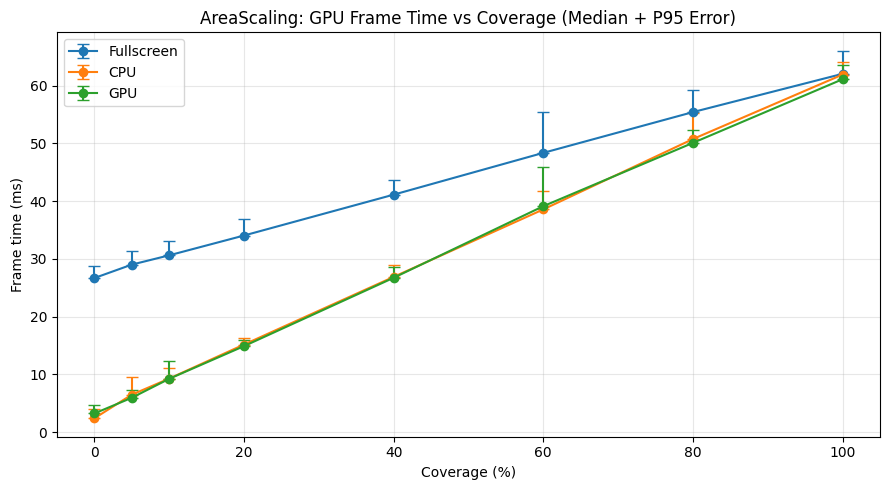

In [26]:
# Median + error bars (p95) for GPU frame times

import matplotlib.pyplot as plt
import numpy as np

area_df = test_dfs["AreaScaling"].sort_values(["value", "render_mode"])

plt.figure(figsize=(9, 5))

for render_mode in ["Fullscreen", "CPU", "GPU"]:
    mode_df = area_df[area_df["render_mode"] == render_mode].sort_values("value")

    x = mode_df["value"].values
    median = mode_df["median_gpu_ms"].values
    p95 = mode_df["p95_gpu_ms"].values

    # asymmetric error: only upward (median -> p95)
    lower_err = np.zeros_like(median)
    upper_err = p95 - median

    plt.errorbar(
        x,
        median,
        yerr=[lower_err, upper_err],
        marker="o",
        capsize=4,
        label=render_mode
    )

# frame budget lines
# plt.axhline(16.67, linestyle="--", label="60 FPS")
# plt.axhline(33.33, linestyle="--", label="30 FPS")

plt.title("AreaScaling: GPU Frame Time vs Coverage (Median + P95 Error)")
plt.xlabel("Coverage (%)")
plt.ylabel("Frame time (ms)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

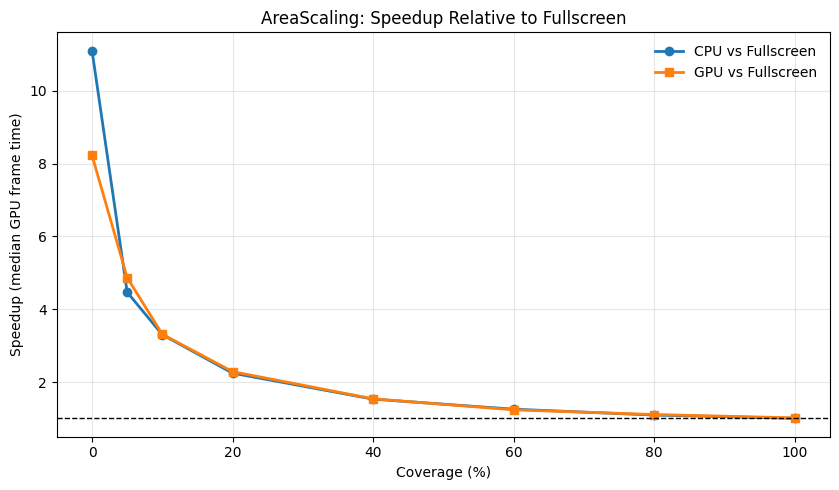

,CPU,GPU
value,,
0,11.099812,8.223922
5,4.465943,4.866439
10,3.299329,3.312034
20,2.243546,2.284862
40,1.529482,1.538265
60,1.253688,1.235987
80,1.091974,1.106379
100,1.002126,1.015343


In [27]:
area_df = test_dfs["AreaScaling"].copy()

pivot = (
    area_df.pivot_table(
        index="value",
        columns="render_mode",
        values="median_gpu_ms",
        aggfunc="mean"
    )
    .sort_index()
)

speedup_df = pd.DataFrame(index=pivot.index)
speedup_df["CPU"] = pivot["Fullscreen"] / pivot["CPU"]
speedup_df["GPU"] = pivot["Fullscreen"] / pivot["GPU"]

plt.figure(figsize=(8.5, 5))

for mode, style in [("CPU", "o-"), ("GPU", "s-")]:
    plt.plot(
        speedup_df.index,
        speedup_df[mode],
        style,
        linewidth=2,
        markersize=6,
        label=f"{mode} vs Fullscreen"
    )

plt.axhline(1.0, linestyle="--", color="black", linewidth=1)

plt.title("AreaScaling: Speedup Relative to Fullscreen")
plt.xlabel("Coverage (%)")
plt.ylabel("Speedup (median GPU frame time)")
plt.grid(True, alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

speedup_df

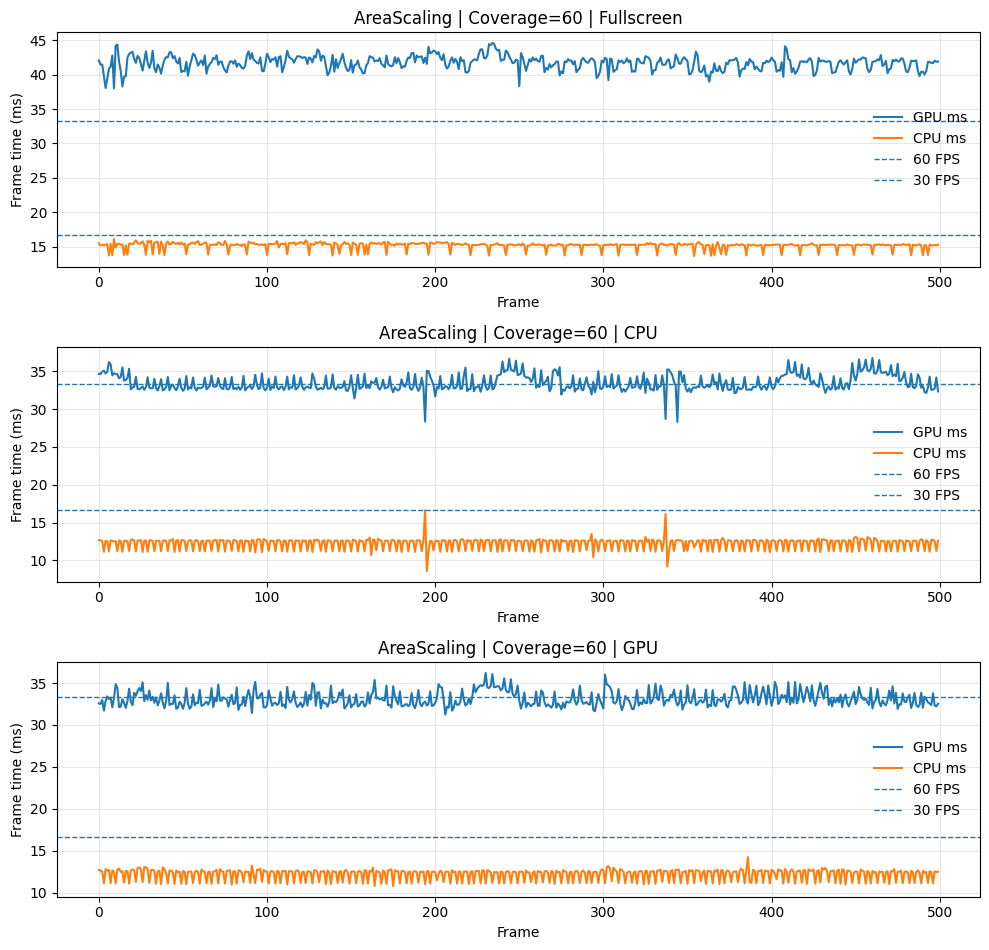

In [28]:
logs_dir = Path("/Users/bigrorz/UnityProjects/MultipleStyleRendering/ProfilingLogs")

selected_runs = [
    ("AreaScaling", 60, "Fullscreen"),
    ("AreaScaling", 60, "CPU"),
    ("AreaScaling", 60, "GPU"),
]

fig, axes = plt.subplots(len(selected_runs), 1, figsize=(10, 3.2 * len(selected_runs)), sharex=False)

if len(selected_runs) == 1:
    axes = [axes]

for ax, (test_name, value, render_mode) in zip(axes, selected_runs):
    frames_path = logs_dir / f"{test_name}_Coverage_{value}_{render_mode}_frames.csv"
    df = pd.read_csv(frames_path)

    ax.plot(df["frame"], df["gpu_ms"], label="GPU ms")
    ax.plot(df["frame"], df["cpu_ms"], label="CPU ms")

    ax.axhline(16.67, linestyle="--", linewidth=1, label="60 FPS")
    ax.axhline(33.33, linestyle="--", linewidth=1, label="30 FPS")

    ax.set_title(f"{test_name} | Coverage={value} | {render_mode}")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Frame time (ms)")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

,test_name,scene,variable,value,render_mode,N,K,styles_per_object,pass_name,mean_cpu_ms,...,p95_cpu_ms,p99_cpu_ms,max_cpu_ms,std_cpu_ms,mean_gpu_ms,median_gpu_ms,p95_gpu_ms,p99_gpu_ms,max_gpu_ms,std_gpu_ms
245,AreaScaling,TestScene3,Coverage,60,CPU,32,32,32,SourcePrepass,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
246,AreaScaling,TestScene3,Coverage,60,CPU,32,32,32,IdPrepass,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
247,AreaScaling,TestScene3,Coverage,60,CPU,32,32,32,BBoxGeneration,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
248,AreaScaling,TestScene3,Coverage,60,CPU,32,32,32,TestEffect_0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
249,AreaScaling,TestScene3,Coverage,60,CPU,32,32,32,TestEffect_1,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1150,AreaScaling,TestScene3,Coverage,60,GPU,32,32,32,TestEffect_27,0.006341,...,0.010877,0.012841,0.030459,0.002792,0.0,0.0,0.0,0.0,0.0,0.0
1151,AreaScaling,TestScene3,Coverage,60,GPU,32,32,32,TestEffect_28,0.006787,...,0.010547,0.027316,0.072208,0.005377,0.0,0.0,0.0,0.0,0.0,0.0
1152,AreaScaling,TestScene3,Coverage,60,GPU,32,32,32,TestEffect_29,0.006260,...,0.010337,0.013336,0.025334,0.002602,0.0,0.0,0.0,0.0,0.0,0.0
1153,AreaScaling,TestScene3,Coverage,60,GPU,32,32,32,TestEffect_30,0.006483,...,0.010923,0.012251,0.066417,0.003690,0.0,0.0,0.0,0.0,0.0,0.0


<Figure size 1000x600 with 0 Axes>

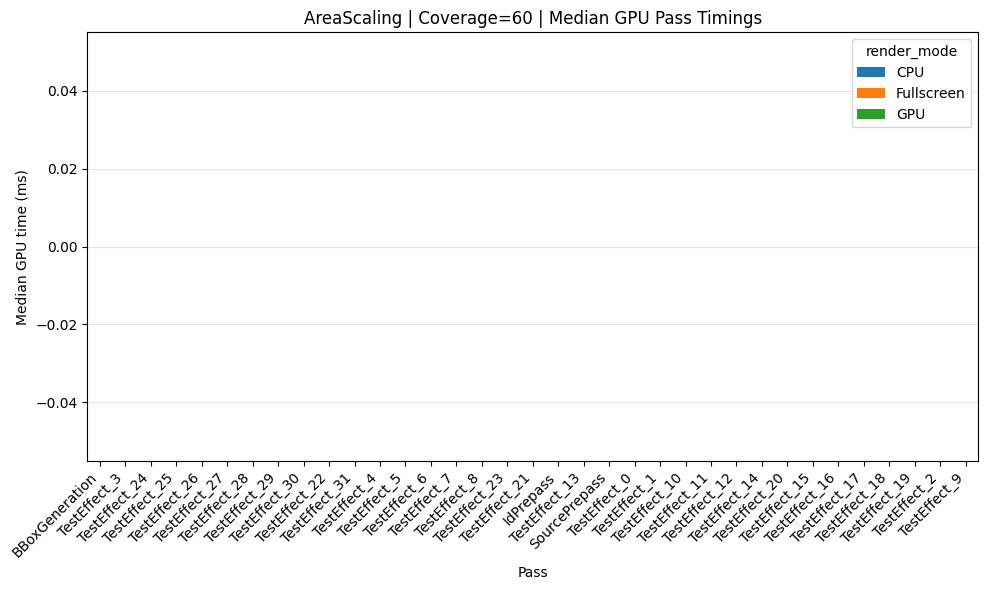

<Figure size 1000x600 with 0 Axes>

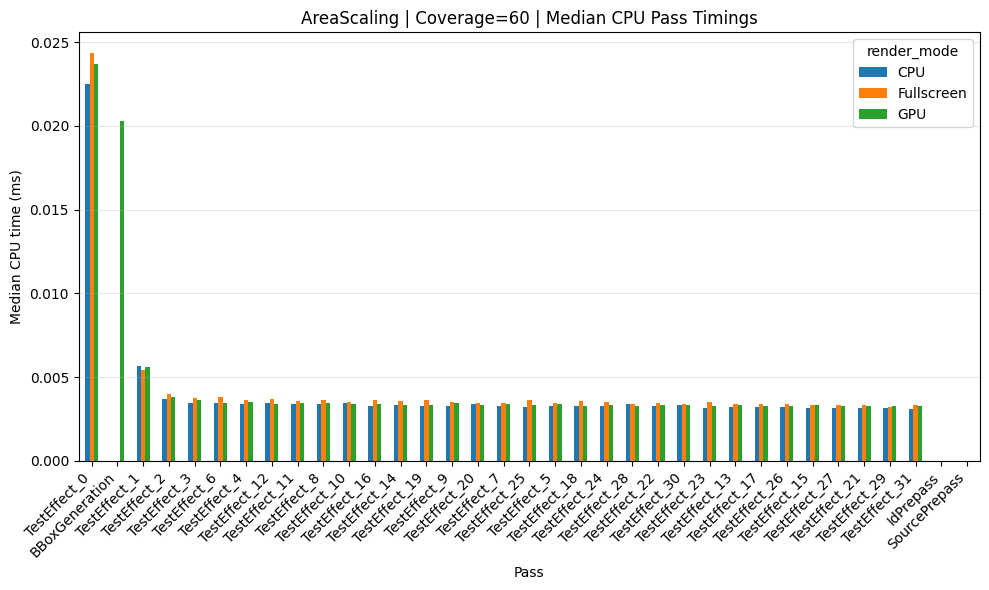

In [29]:
pass_summary_path = Path("/Users/bigrorz/UnityProjects/MultipleStyleRendering/ProfilingLogs/pass_summary.csv")
pass_df = pd.read_csv(pass_summary_path)

# pick the run you want to inspect
test_name = "AreaScaling"
value = 60

run_df = (
    pass_df[
        (pass_df["test_name"] == test_name) &
        (pass_df["value"] == value)
    ]
    .copy()
    .sort_values(["render_mode", "median_gpu_ms"], ascending=[True, False])
)

display(run_df)

# median GPU pass breakdown
pivot_gpu = run_df.pivot_table(
    index="pass_name",
    columns="render_mode",
    values="median_gpu_ms",
    aggfunc="mean"
).fillna(0)

pivot_gpu = pivot_gpu.loc[pivot_gpu.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(10, 6))
pivot_gpu.plot(kind="bar", figsize=(10, 6))
plt.title(f"{test_name} | Coverage={value} | Median GPU Pass Timings")
plt.xlabel("Pass")
plt.ylabel("Median GPU time (ms)")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# median CPU pass breakdown
pivot_cpu = run_df.pivot_table(
    index="pass_name",
    columns="render_mode",
    values="median_cpu_ms",
    aggfunc="mean"
).fillna(0)

pivot_cpu = pivot_cpu.loc[pivot_cpu.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(10, 6))
pivot_cpu.plot(kind="bar", figsize=(10, 6))
plt.title(f"{test_name} | Coverage={value} | Median CPU Pass Timings")
plt.xlabel("Pass")
plt.ylabel("Median CPU time (ms)")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()